In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

DATA_DIR = "../data/processed"

print("Advanced Analytics started")
print("Data directory:", DATA_DIR)

Advanced Analytics started
Data directory: ../data/processed


In [2]:
import os

files = os.listdir(DATA_DIR)

print("Files available in processed data:")
for file in files:
    print(file)

Files available in processed data:
01_fund_master.csv
02_nav_history.csv
03_aum_by_fund_house.csv
04_monthly_sip_inflows.csv
05_category_inflows.csv
06_industry_folio_count.csv
07_scheme_performance.csv
08_investor_transactions.csv
09_portfolio_holdings.csv
10_benchmark_indices.csv


In [3]:
# Load the main datasets needed for risk analysis

nav = pd.read_csv(os.path.join(DATA_DIR, "02_nav_history.csv"))
scheme_perf = pd.read_csv(os.path.join(DATA_DIR, "07_scheme_performance.csv"))

print("NAV History:")
print(nav.shape)
print(nav.columns.tolist())

print("\nScheme Performance:")
print(scheme_perf.shape)
print(scheme_perf.columns.tolist())

NAV History:
(46000, 3)
['amfi_code', 'date', 'nav']

Scheme Performance:
(40, 19)
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [4]:
print("NAV History sample:")
display(nav.head())

print("\nScheme Performance sample:")
display(scheme_perf.head())

NAV History sample:


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639



Scheme Performance sample:


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [5]:
# Prepare NAV data for risk analysis

nav["date"] = pd.to_datetime(nav["date"])
nav["nav"] = pd.to_numeric(nav["nav"], errors="coerce")

# Sort by scheme and date
nav = nav.sort_values(["amfi_code", "date"])

# Calculate daily percentage return for each scheme
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

# Remove missing returns
returns = nav.dropna(subset=["daily_return"]).copy()

print("Total return observations:", len(returns))
print("Number of schemes:", returns["amfi_code"].nunique())

display(returns.head())

Total return observations: 45960
Number of schemes: 40


,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639


In [6]:
# Historical VaR (95%) and CVaR for all schemes

risk_results = []

for amfi_code, group in returns.groupby("amfi_code"):
    
    daily_returns = group["daily_return"].dropna()
    
    # 5th percentile = 95% Historical VaR threshold
    var_95 = daily_returns.quantile(0.05)
    
    # CVaR = average of returns below or equal to VaR
    cvar_95 = daily_returns[daily_returns <= var_95].mean()
    
    risk_results.append({
        "amfi_code": amfi_code,
        "VaR_95": var_95,
        "CVaR_95": cvar_95,
        "observations": len(daily_returns)
    })

var_cvar_report = pd.DataFrame(risk_results)

print("VaR/CVaR calculation completed.")
print("Schemes analyzed:", len(var_cvar_report))

display(var_cvar_report.head(10))

VaR/CVaR calculation completed.
Schemes analyzed: 40


,amfi_code,VaR_95,CVaR_95,observations
0,100016,-0.014364,-0.018060,1149
1,100025,-0.003793,-0.004994,1149
2,100033,-0.019034,-0.023456,1149
3,101206,-0.013282,-0.017439,1149
4,101207,-0.026021,-0.032459,1149
5,101208,-0.000269,-0.000422,1149
6,102885,-0.012613,-0.015490,1149
7,102886,-0.019220,-0.023251,1149
8,102887,-0.015232,-0.019411,1149
9,118632,-0.013954,-0.017619,1149


In [7]:
# Save required deliverable

REPORT_DIR = "reports"
os.makedirs(REPORT_DIR, exist_ok=True)

output_path = os.path.join(REPORT_DIR, "var_cvar_report.csv")

var_cvar_report.to_csv(output_path, index=False)

print("Saved successfully:")
print(output_path)

Saved successfully:
reports\var_cvar_report.csv


In [8]:
# Rolling 90-day Sharpe Ratio for 5 key funds

# Select 5 funds from the available schemes
key_funds = scheme_perf["amfi_code"].head(5).tolist()

print("Selected 5 key funds:")
print(key_funds)

Selected 5 key funds:
[119551, 119552, 119598, 119599, 119120]


In [9]:
# Calculate rolling 90-day Sharpe ratio

sharpe_data = returns[returns["amfi_code"].isin(key_funds)].copy()

sharpe_data = sharpe_data.sort_values(["amfi_code", "date"])

sharpe_data["rolling_mean"] = (
    sharpe_data.groupby("amfi_code")["daily_return"]
    .transform(lambda x: x.rolling(90).mean())
)

sharpe_data["rolling_std"] = (
    sharpe_data.groupby("amfi_code")["daily_return"]
    .transform(lambda x: x.rolling(90).std())
)

sharpe_data["rolling_sharpe"] = (
    sharpe_data["rolling_mean"] /
    sharpe_data["rolling_std"]
) * np.sqrt(252)

print("Rolling 90-day Sharpe calculation completed.")

display(
    sharpe_data[
        ["amfi_code", "date", "rolling_sharpe"]
    ].dropna().head(10)
)

Rolling 90-day Sharpe calculation completed.


,amfi_code,date,rolling_sharpe
20790,119120,2022-05-09,0.634879
20791,119120,2022-05-10,0.521896
20792,119120,2022-05-11,0.411288
20793,119120,2022-05-12,0.281241
20794,119120,2022-05-13,0.436266
20795,119120,2022-05-16,0.445791
20796,119120,2022-05-17,0.590883
20797,119120,2022-05-18,0.718940
20798,119120,2022-05-19,0.625900
20799,119120,2022-05-20,0.690036


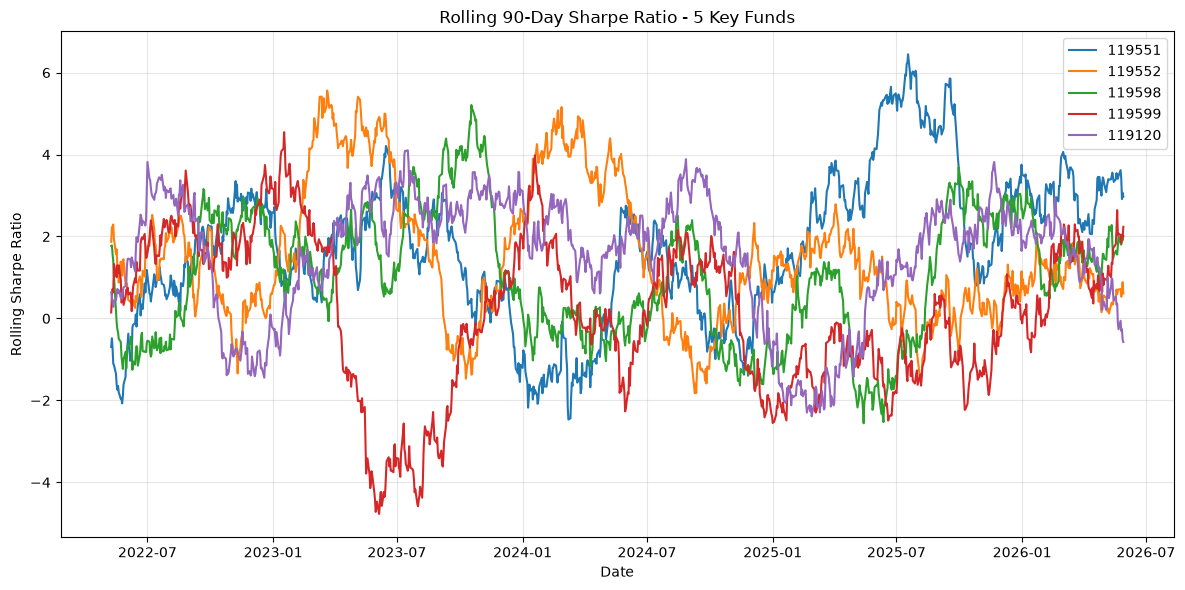

Chart saved:
reports\rolling_sharpe_chart.png


In [10]:
# Plot rolling 90-day Sharpe ratio

plt.figure(figsize=(12, 6))

for fund in key_funds:
    fund_data = sharpe_data[
        sharpe_data["amfi_code"] == fund
    ].dropna(subset=["rolling_sharpe"])
    
    plt.plot(
        fund_data["date"],
        fund_data["rolling_sharpe"],
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio - 5 Key Funds")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

sharpe_chart_path = os.path.join(
    REPORT_DIR,
    "rolling_sharpe_chart.png"
)

plt.savefig(
    sharpe_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved:")
print(sharpe_chart_path)

In [11]:
# Load investor transaction data
transactions = pd.read_csv(
    os.path.join(DATA_DIR, "08_investor_transactions.csv")
)

print("Investor Transactions:")
print(transactions.shape)
print(transactions.columns.tolist())

display(transactions.head())

Investor Transactions:
(32778, 13)
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,VERIFIED
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,VERIFIED
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,VERIFIED
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,PENDING
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,PENDING


In [12]:
# Convert transaction date to datetime
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

# Find each investor's first transaction
first_transaction = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

# Create cohort year
first_transaction["cohort_year"] = (
    first_transaction["transaction_date"].dt.year
)

# Add cohort year back to transaction data
transactions = transactions.merge(
    first_transaction[["investor_id", "cohort_year"]],
    on="investor_id",
    how="left"
)

print("Cohort years created successfully")
display(
    transactions[
        ["investor_id", "transaction_date", "transaction_type",
         "amount_inr", "cohort_year"]
    ].head(10)
)

Cohort years created successfully


,investor_id,transaction_date,transaction_type,amount_inr,cohort_year
0,INV003054,2024-01-01,SIP,1834,2024
1,INV002952,2024-01-01,REDEMPTION,392882,2024
2,INV003420,2024-01-01,SIP,912,2024
3,INV003436,2024-01-01,SIP,1102,2024
4,INV004691,2024-01-01,LUMPSUM,8682,2024
5,INV001497,2024-01-01,SIP,3295,2024
6,INV000786,2024-01-01,SIP,15047,2024
7,INV000616,2024-01-01,SIP,933,2024
8,INV003670,2024-01-01,SIP,10672,2024
9,INV002054,2024-01-01,SIP,1111,2024


In [13]:
# Filter investment transactions
investment_txns = transactions[
    transactions["transaction_type"].isin(["SIP", "LUMPSUM"])
].copy()

# 1. Average SIP amount by cohort
avg_sip = (
    transactions[transactions["transaction_type"] == "SIP"]
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index(name="average_sip_amount")
)

# 2. Total invested amount by cohort
total_invested = (
    investment_txns
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="total_invested")
)

# 3. Top fund preference by cohort
sip_txns = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

top_fund = (
    sip_txns
    .groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="sip_transactions")
    .sort_values(
        ["cohort_year", "sip_transactions"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
    .rename(columns={"amfi_code": "top_fund"})
)

# Combine all cohort metrics
cohort_analysis = (
    avg_sip
    .merge(total_invested, on="cohort_year", how="outer")
    .merge(
        top_fund[["cohort_year", "top_fund"]],
        on="cohort_year",
        how="outer"
    )
    .sort_values("cohort_year")
)

# Display final cohort analysis
print("Investor Cohort Analysis")
display(cohort_analysis)

Investor Cohort Analysis


,cohort_year,average_sip_amount,total_invested,top_fund
0,2024,10996.885825,2258062304,120504
1,2025,13505.209581,18992635,119599


In [14]:
# Save Investor Cohort Analysis
cohort_output_path = os.path.join(
    REPORT_DIR,
    "investor_cohort_analysis.csv"
)

cohort_analysis.to_csv(
    cohort_output_path,
    index=False
)

print("Investor Cohort Analysis saved successfully:")
print(cohort_output_path)

Investor Cohort Analysis saved successfully:
reports\investor_cohort_analysis.csv


In [15]:
# Filter SIP transactions only
sip_transactions = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

# Sort by investor and transaction date
sip_transactions = sip_transactions.sort_values(
    ["investor_id", "transaction_date"]
)

print("SIP transactions:", len(sip_transactions))
display(sip_transactions.head())

SIP transactions: 19716


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,VERIFIED,2024
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,PENDING,2024
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,VERIFIED,2024
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,VERIFIED,2024
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,VERIFIED,2024


In [16]:
# Calculate the gap between consecutive SIP transactions
sip_transactions["previous_sip_date"] = (
    sip_transactions
    .groupby("investor_id")["transaction_date"]
    .shift(1)
)

sip_transactions["sip_gap_days"] = (
    sip_transactions["transaction_date"]
    - sip_transactions["previous_sip_date"]
).dt.days

print("SIP gaps calculated successfully")

display(
    sip_transactions[
        [
            "investor_id",
            "transaction_date",
            "previous_sip_date",
            "sip_gap_days"
        ]
    ].head(10)
)

SIP gaps calculated successfully


,investor_id,transaction_date,previous_sip_date,sip_gap_days
19621,INV000001,2024-11-04,NaT,NaN
24448,INV000001,2025-01-19,2024-11-04,76.0
5650,INV000002,2024-03-29,NaT,NaN
16803,INV000002,2024-09-21,2024-03-29,176.0
31881,INV000002,2025-05-17,2024-09-21,238.0
12652,INV000003,2024-07-16,NaT,NaN
27622,INV000003,2025-03-11,2024-07-16,238.0
4773,INV000004,2024-03-16,NaT,NaN
6418,INV000004,2024-04-11,2024-03-16,26.0
8271,INV000004,2024-05-09,2024-04-11,28.0


In [17]:
# Count SIP transactions for each investor
sip_counts = (
    sip_transactions
    .groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

# Keep investors with 6 or more SIP transactions
eligible_investors = sip_counts[
    sip_counts["sip_count"] >= 6
].copy()

print("Total investors with 6+ SIP transactions:",
      len(eligible_investors))

display(eligible_investors.head(10))

Total investors with 6+ SIP transactions: 1362


,investor_id,sip_count
3,INV000004,6
7,INV000008,6
9,INV000010,6
10,INV000011,7
11,INV000012,8
12,INV000013,7
13,INV000014,7
22,INV000023,8
27,INV000028,6
28,INV000029,7


In [18]:
# Calculate average SIP gap for eligible investors
sip_continuity = (
    sip_transactions[
        sip_transactions["investor_id"].isin(
            eligible_investors["investor_id"]
        )
    ]
    .groupby("investor_id")
    .agg(
        sip_count=("transaction_date", "count"),
        avg_sip_gap_days=("sip_gap_days", "mean"),
        max_sip_gap_days=("sip_gap_days", "max")
    )
    .reset_index()
)

# Flag investors with any SIP gap > 35 days
sip_continuity["at_risk"] = (
    sip_continuity["max_sip_gap_days"] > 35
)

print("SIP Continuity Analysis:")
display(sip_continuity.head(10))

SIP Continuity Analysis:


,investor_id,sip_count,avg_sip_gap_days,max_sip_gap_days,at_risk
0,INV000004,6,85.400000,265.0,True
1,INV000008,6,70.400000,165.0,True
2,INV000010,6,64.800000,139.0,True
3,INV000011,7,40.166667,125.0,True
4,INV000012,8,57.000000,132.0,True
5,INV000013,7,55.333333,104.0,True
6,INV000014,7,75.333333,128.0,True
7,INV000023,8,58.571429,115.0,True
8,INV000028,6,93.600000,238.0,True
9,INV000029,7,60.666667,96.0,True


In [19]:
# Save SIP Continuity Analysis
sip_continuity_output_path = os.path.join(
    REPORT_DIR,
    "sip_continuity_analysis.csv"
)

sip_continuity.to_csv(
    sip_continuity_output_path,
    index=False
)

print("SIP Continuity Analysis saved successfully:")
print(sip_continuity_output_path)

SIP Continuity Analysis saved successfully:
reports\sip_continuity_analysis.csv


In [20]:
# Simple Fund Recommender

def recommend_funds(risk_appetite):
    risk_appetite = risk_appetite.strip().title()

    valid_risks = ["Low", "Moderate", "High"]

    if risk_appetite not in valid_risks:
        print("Invalid risk appetite. Choose Low, Moderate, or High.")
        return pd.DataFrame()

    recommendations = (
        scheme_perf[
            scheme_perf["risk_grade"].str.title() == risk_appetite
        ]
        .sort_values("sharpe_ratio", ascending=False)
        .head(3)
        [
            [
                "amfi_code",
                "scheme_name",
                "fund_house",
                "category",
                "risk_grade",
                "sharpe_ratio"
            ]
        ]
    )

    return recommendations


# Example recommendation
risk_appetite = "Moderate"

recommendation = recommend_funds(risk_appetite)

print(f"Top 3 funds for {risk_appetite} risk appetite:")
display(recommendation)

Top 3 funds for Moderate risk appetite:


,amfi_code,scheme_name,fund_house,category,risk_grade,sharpe_ratio
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Moderate,1.06
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Moderate,1.06
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Moderate,1.03


In [21]:
# Save fund recommendation output

recommendation_output_path = os.path.join(
    REPORT_DIR,
    "fund_recommendations.csv"
)

recommendation.to_csv(
    recommendation_output_path,
    index=False
)

print("Fund recommendations saved successfully:")
print(recommendation_output_path)

Fund recommendations saved successfully:
reports\fund_recommendations.csv


In [22]:
# Sector HHI Concentration Analysis

# Load industry/sector allocation data
industry_folio = pd.read_csv(
    os.path.join(DATA_DIR, "06_industry_folio_count.csv")
)

print("Industry Folio Data:")
print(industry_folio.shape)
print(industry_folio.columns.tolist())

display(industry_folio.head())

Industry Folio Data:
(21, 6)
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


In [23]:
# Find the dataset containing sector / allocation / weight information

print("Checking processed datasets for sector and weight columns...\n")

for file in os.listdir(DATA_DIR):
    if file.endswith(".csv"):
        path = os.path.join(DATA_DIR, file)
        
        try:
            df_temp = pd.read_csv(path, nrows=5)
            columns = [str(c).lower() for c in df_temp.columns]
            
            relevant = [
                c for c in columns
                if any(word in c for word in [
                    "sector", "industry", "weight", "allocation"
                ])
            ]
            
            if relevant:
                print(f"File: {file}")
                print("Relevant columns:", relevant)
                print("All columns:", df_temp.columns.tolist())
                print()
                
        except Exception as e:
            print(f"Could not read {file}: {e}")

Checking processed datasets for sector and weight columns...

File: 09_portfolio_holdings.csv
Relevant columns: ['sector', 'weight_pct']
All columns: ['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']



In [24]:
# Sector HHI Concentration Analysis

# Load portfolio holdings
portfolio = pd.read_csv(
    os.path.join(DATA_DIR, "09_portfolio_holdings.csv")
)

# Keep required columns
hhi_data = portfolio[
    ["amfi_code", "sector", "weight_pct"]
].copy()

# Remove missing values
hhi_data = hhi_data.dropna(
    subset=["amfi_code", "sector", "weight_pct"]
)

# Make sure weight is numeric
hhi_data["weight_pct"] = pd.to_numeric(
    hhi_data["weight_pct"],
    errors="coerce"
)

hhi_data = hhi_data.dropna(
    subset=["weight_pct"]
)

# Calculate total sector weight for each fund
sector_weights = (
    hhi_data
    .groupby(["amfi_code", "sector"])["weight_pct"]
    .sum()
    .reset_index()
)

# Convert percentage weights to decimal weights
sector_weights["weight"] = (
    sector_weights["weight_pct"] / 100
)

# HHI = sum of squared sector weights
hhi_analysis = (
    sector_weights
    .groupby("amfi_code")
    .agg(
        hhi=("weight", lambda x: (x ** 2).sum()),
        sector_count=("sector", "nunique")
    )
    .reset_index()
)

# Convert HHI to the standard 0-10,000 scale
hhi_analysis["hhi_10000"] = (
    hhi_analysis["hhi"] * 10000
)

# Add concentration classification
def classify_hhi(hhi):
    if hhi < 1500:
        return "Low Concentration"
    elif hhi < 2500:
        return "Moderate Concentration"
    else:
        return "High Concentration"

hhi_analysis["concentration"] = (
    hhi_analysis["hhi_10000"]
    .apply(classify_hhi)
)

# Sort from highest to lowest concentration
hhi_analysis = hhi_analysis.sort_values(
    "hhi_10000",
    ascending=False
)

print("Sector HHI Concentration Analysis")
display(hhi_analysis.head(20))

Sector HHI Concentration Analysis


,amfi_code,hhi,sector_count,hhi_10000,concentration
11,119092,0.296769,7,2967.6909,High Concentration
30,148569,0.254992,7,2549.9194,High Concentration
27,125498,0.253155,6,2531.5500,High Concentration
6,102887,0.251383,6,2513.8255,High Concentration
32,149323,0.241077,7,2410.7664,Moderate Concentration
21,120505,0.238695,7,2386.9504,Moderate Concentration
10,118635,0.237497,6,2374.9677,Moderate Concentration
18,119599,0.232361,7,2323.6120,Moderate Concentration
22,120506,0.231464,7,2314.6434,Moderate Concentration
1,100033,0.227647,7,2276.4744,Moderate Concentration


In [25]:
# Save Sector HHI Analysis

hhi_output_path = os.path.join(
    REPORT_DIR,
    "sector_hhi_analysis.csv"
)

hhi_analysis.to_csv(
    hhi_output_path,
    index=False
)

print("Sector HHI Analysis saved successfully:")
print(hhi_output_path)

Sector HHI Analysis saved successfully:
reports\sector_hhi_analysis.csv


In [26]:
# Advanced Insight 1: Fund Risk vs Return Analysis

fund_risk_return = scheme_perf[
    [
        "amfi_code",
        "scheme_name",
        "category",
        "return_3yr_pct",
        "sharpe_ratio",
        "sortino_ratio",
        "std_dev"
    ]
].copy()

fund_risk_return = fund_risk_return.sort_values(
    "sharpe_ratio",
    ascending=False
)

print("Fund Risk vs Return Analysis")
display(fund_risk_return.head(20))

KeyError: "['std_dev'] not in index"

In [27]:
# Check exact columns available in Scheme Performance

print("Scheme Performance columns:")
for i, col in enumerate(scheme_perf.columns):
    print(i, "->", col)

Scheme Performance columns:
0 -> amfi_code
1 -> scheme_name
2 -> fund_house
3 -> category
4 -> plan
5 -> return_1yr_pct
6 -> return_3yr_pct
7 -> return_5yr_pct
8 -> benchmark_3yr_pct
9 -> alpha
10 -> beta
11 -> sharpe_ratio
12 -> sortino_ratio
13 -> std_dev_ann_pct
14 -> max_drawdown_pct
15 -> aum_crore
16 -> expense_ratio_pct
17 -> morningstar_rating
18 -> risk_grade


In [28]:
# Advanced Insight 1: Fund Risk vs Return Analysis

fund_risk_return = scheme_perf[
    [
        "amfi_code",
        "scheme_name",
        "category",
        "return_3yr_pct",
        "sharpe_ratio",
        "sortino_ratio",
        "std_dev_ann_pct"
    ]
].copy()

fund_risk_return = fund_risk_return.sort_values(
    "sharpe_ratio",
    ascending=False
)

print("Fund Risk vs Return Analysis")
display(fund_risk_return.head(20))

Fund Risk vs Return Analysis


,amfi_code,scheme_name,category,return_3yr_pct,sharpe_ratio,sortino_ratio,std_dev_ann_pct
14,120507,ICICI Pru Liquid Fund - Regular - Growth,Liquid,7.68,7.68,10.37,0.5
23,120844,Kotak Liquid Fund - Regular - Growth,Liquid,6.18,6.18,9.70,0.5
30,101208,ABSL Liquid Fund - Regular - Growth,Liquid,5.14,5.14,8.76,0.5
9,100025,HDFC Short Term Debt Fund - Regular - Growth,Short Duration,7.37,1.84,2.79,4.0
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,Gilt,6.07,1.52,2.11,4.0
19,118636,Nippon India Gilt Securities Fund - Regular - ...,Gilt,5.31,1.33,2.38,4.0
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Large Cap,14.81,1.06,1.66,14.0
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,Large Cap,14.84,1.06,1.70,14.0
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,Large Cap,14.41,1.03,1.27,14.0
15,118632,Nippon India Large Cap Fund - Regular - Growth,Large Cap,14.00,1.00,1.68,14.0


In [29]:
# Save Fund Risk vs Return Analysis

risk_return_output_path = os.path.join(
    REPORT_DIR,
    "fund_risk_return_analysis.csv"
)

fund_risk_return.to_csv(
    risk_return_output_path,
    index=False
)

print("Fund Risk vs Return Analysis saved successfully:")
print(risk_return_output_path)

Fund Risk vs Return Analysis saved successfully:
reports\fund_risk_return_analysis.csv


In [30]:
# Advanced Insight 2: Risk-Adjusted Fund Ranking

fund_ranking = scheme_perf[
    [
        "amfi_code",
        "scheme_name",
        "category",
        "return_3yr_pct",
        "sharpe_ratio",
        "sortino_ratio",
        "risk_grade"
    ]
].copy()

# Create a combined score
fund_ranking["risk_adjusted_score"] = (
    fund_ranking["return_3yr_pct"] * 0.4
    + fund_ranking["sharpe_ratio"] * 30 * 0.35
    + fund_ranking["sortino_ratio"] * 20 * 0.25
)

fund_ranking = fund_ranking.sort_values(
    "risk_adjusted_score",
    ascending=False
)

print("Risk-Adjusted Fund Ranking")
display(fund_ranking.head(20))

Risk-Adjusted Fund Ranking


,amfi_code,scheme_name,category,return_3yr_pct,sharpe_ratio,sortino_ratio,risk_grade,risk_adjusted_score
14,120507,ICICI Pru Liquid Fund - Regular - Growth,Liquid,7.68,7.68,10.37,Low,135.562
23,120844,Kotak Liquid Fund - Regular - Growth,Liquid,6.18,6.18,9.70,Low,115.862
30,101208,ABSL Liquid Fund - Regular - Growth,Liquid,5.14,5.14,8.76,Low,99.826
9,100025,HDFC Short Term Debt Fund - Regular - Growth,Short Duration,7.37,1.84,2.79,Low,36.218
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,Gilt,6.07,1.52,2.11,Low,28.938
19,118636,Nippon India Gilt Securities Fund - Regular - ...,Gilt,5.31,1.33,2.38,Low,27.989
3,119599,SBI Small Cap Fund - Direct Plan - Growth,Small Cap,23.14,0.93,1.67,Very High,27.371
2,119598,SBI Small Cap Fund - Regular Plan - Growth,Small Cap,23.39,0.94,1.35,Very High,25.976
29,101207,ABSL Small Cap Fund - Regular - Growth,Small Cap,22.38,0.90,1.47,Very High,25.752
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,Large Cap,14.84,1.06,1.70,Moderate,25.566


In [31]:
# Save Risk-Adjusted Fund Ranking

ranking_output_path = os.path.join(
    REPORT_DIR,
    "risk_adjusted_fund_ranking.csv"
)

fund_ranking.to_csv(
    ranking_output_path,
    index=False
)

print("Risk-Adjusted Fund Ranking saved successfully:")
print(ranking_output_path)

Risk-Adjusted Fund Ranking saved successfully:
reports\risk_adjusted_fund_ranking.csv


In [32]:
# Advanced Insight 3: Category-Level Risk Analysis

category_risk = (
    scheme_perf
    .groupby("category")
    .agg(
        fund_count=("amfi_code", "count"),
        avg_return_3yr=("return_3yr_pct", "mean"),
        avg_sharpe_ratio=("sharpe_ratio", "mean"),
        avg_sortino_ratio=("sortino_ratio", "mean"),
        avg_volatility=("std_dev_ann_pct", "mean")
    )
    .reset_index()
)

category_risk = category_risk.sort_values(
    "avg_return_3yr",
    ascending=False
)

print("Category-Level Risk Analysis")
display(category_risk)

Category-Level Risk Analysis


,category,fund_count,avg_return_3yr,avg_sharpe_ratio,avg_sortino_ratio,avg_volatility
10,Small Cap,6,21.686667,0.870000,1.376667,25.0
8,Mid Cap,7,16.590000,0.871429,1.347143,19.0
1,Flexi Cap,2,15.495000,0.970000,1.470000,16.0
11,Value,1,14.760000,0.980000,1.500000,15.0
5,Large & Mid Cap,1,14.560000,0.910000,1.550000,16.0
0,ELSS,1,13.580000,0.800000,1.030000,17.0
6,Large Cap,14,12.985714,0.927857,1.425000,14.0
3,Index,1,12.100000,0.930000,1.290000,13.0
4,Index/ETF,1,11.770000,0.910000,1.240000,13.0
9,Short Duration,1,7.370000,1.840000,2.790000,4.0


In [33]:
# Save Category-Level Risk Analysis

category_risk_output_path = os.path.join(
    REPORT_DIR,
    "category_risk_analysis.csv"
)

category_risk.to_csv(
    category_risk_output_path,
    index=False
)

print("Category-Level Risk Analysis saved successfully:")
print(category_risk_output_path)

Category-Level Risk Analysis saved successfully:
reports\category_risk_analysis.csv


In [37]:
# Save Category Risk-Adjusted Ranking

category_ranking_output_path = os.path.join(
    REPORT_DIR,
    "category_risk_adjusted_ranking.csv"
)

category_risk_ranked.to_csv(
    category_ranking_output_path,
    index=False
)

print("Category Risk-Adjusted Ranking saved successfully:")
print(category_ranking_output_path)

Category Risk-Adjusted Ranking saved successfully:
reports\category_risk_adjusted_ranking.csv


In [35]:
# Step 35: Category Risk-Adjusted Ranking

category_risk_ranked = category_risk.copy()

category_risk_ranked["risk_adjusted_score"] = (
    category_risk_ranked["avg_return_3yr"]
    / category_risk_ranked["avg_volatility"]
)

category_risk_ranked = category_risk_ranked.sort_values(
    "risk_adjusted_score",
    ascending=False
).reset_index(drop=True)

print("Category Risk-Adjusted Ranking")
display(category_risk_ranked)

Category Risk-Adjusted Ranking


,category,fund_count,avg_return_3yr,avg_sharpe_ratio,avg_sortino_ratio,avg_volatility,risk_adjusted_score
0,Liquid,3,6.333333,6.333333,9.610000,0.5,12.666667
1,Short Duration,1,7.370000,1.840000,2.790000,4.0,1.842500
2,Gilt,2,5.690000,1.425000,2.245000,4.0,1.422500
3,Value,1,14.760000,0.980000,1.500000,15.0,0.984000
4,Flexi Cap,2,15.495000,0.970000,1.470000,16.0,0.968438
5,Index,1,12.100000,0.930000,1.290000,13.0,0.930769
6,Large Cap,14,12.985714,0.927857,1.425000,14.0,0.927551
7,Large & Mid Cap,1,14.560000,0.910000,1.550000,16.0,0.910000
8,Index/ETF,1,11.770000,0.910000,1.240000,13.0,0.905385
9,Mid Cap,7,16.590000,0.871429,1.347143,19.0,0.873158


In [36]:
# Save Category Risk-Adjusted Ranking

category_ranking_output_path = os.path.join(
    REPORT_DIR,
    "category_risk_adjusted_ranking.csv"
)

category_risk_ranked.to_csv(
    category_ranking_output_path,
    index=False
)

print("Category Risk-Adjusted Ranking saved successfully:")
print(category_ranking_output_path)

Category Risk-Adjusted Ranking saved successfully:
reports\category_risk_adjusted_ranking.csv


In [38]:
# Advanced Insight 4: Best Performing Category

best_category = category_risk_ranked.iloc[0]

print("Best Risk-Adjusted Category")
print("--------------------------------")
print("Category:", best_category["category"])
print("Average 3-Year Return:", round(best_category["avg_return_3yr"], 2), "%")
print("Average Volatility:", round(best_category["avg_volatility"], 2), "%")
print("Risk-Adjusted Score:", round(best_category["risk_adjusted_score"], 2))

Best Risk-Adjusted Category
--------------------------------
Category: Liquid
Average 3-Year Return: 6.33 %
Average Volatility: 0.5 %
Risk-Adjusted Score: 12.67


In [39]:
# Step 38: Save Best Performing Category Insight

best_category_output = pd.DataFrame([{
    "best_category": best_category["category"],
    "average_3yr_return_pct": best_category["avg_return_3yr"],
    "average_volatility_pct": best_category["avg_volatility"],
    "risk_adjusted_score": best_category["risk_adjusted_score"]
}])

best_category_output_path = os.path.join(
    REPORT_DIR,
    "best_category_insight.csv"
)

best_category_output.to_csv(
    best_category_output_path,
    index=False
)

print("Best Category Insight saved successfully:")
print(best_category_output_path)

display(best_category_output)

Best Category Insight saved successfully:
reports\best_category_insight.csv


,best_category,average_3yr_return_pct,average_volatility_pct,risk_adjusted_score
0,Liquid,6.333333,0.5,12.666667


In [40]:
# Advanced Insight 5: Category Return vs Risk Comparison

category_comparison = category_risk_ranked[
    [
        "category",
        "avg_return_3yr",
        "avg_volatility",
        "risk_adjusted_score"
    ]
].copy()

category_comparison = category_comparison.sort_values(
    "avg_return_3yr",
    ascending=False
).reset_index(drop=True)

print("Category Return vs Risk Comparison")
display(category_comparison)

Category Return vs Risk Comparison


,category,avg_return_3yr,avg_volatility,risk_adjusted_score
0,Small Cap,21.686667,25.0,0.867467
1,Mid Cap,16.590000,19.0,0.873158
2,Flexi Cap,15.495000,16.0,0.968438
3,Value,14.760000,15.0,0.984000
4,Large & Mid Cap,14.560000,16.0,0.910000
5,ELSS,13.580000,17.0,0.798824
6,Large Cap,12.985714,14.0,0.927551
7,Index,12.100000,13.0,0.930769
8,Index/ETF,11.770000,13.0,0.905385
9,Short Duration,7.370000,4.0,1.842500


In [41]:
# Step 40: Save Category Return vs Risk Comparison

category_comparison_output_path = os.path.join(
    REPORT_DIR,
    "category_return_vs_risk.csv"
)

category_comparison.to_csv(
    category_comparison_output_path,
    index=False
)

print("Category Return vs Risk Comparison saved successfully:")
print(category_comparison_output_path)

Category Return vs Risk Comparison saved successfully:
reports\category_return_vs_risk.csv


In [42]:
# Step 41: Identify Best Return and Lowest Risk Categories

# Category with highest 3-year return
highest_return_category = category_comparison.loc[
    category_comparison["avg_return_3yr"].idxmax()
]

# Category with lowest volatility
lowest_risk_category = category_comparison.loc[
    category_comparison["avg_volatility"].idxmin()
]

print("Category Performance Insights")
print("-" * 40)

print("\nHighest 3-Year Return:")
print("Category:", highest_return_category["category"])
print(
    "Average 3-Year Return:",
    round(highest_return_category["avg_return_3yr"], 2),
    "%"
)
print(
    "Average Volatility:",
    round(highest_return_category["avg_volatility"], 2),
    "%"
)

print("\nLowest Risk / Volatility:")
print("Category:", lowest_risk_category["category"])
print(
    "Average 3-Year Return:",
    round(lowest_risk_category["avg_return_3yr"], 2),
    "%"
)
print(
    "Average Volatility:",
    round(lowest_risk_category["avg_volatility"], 2),
    "%"
)

Category Performance Insights
----------------------------------------

Highest 3-Year Return:
Category: Small Cap
Average 3-Year Return: 21.69 %
Average Volatility: 25.0 %

Lowest Risk / Volatility:
Category: Liquid
Average 3-Year Return: 6.33 %
Average Volatility: 0.5 %


In [43]:
# Step 42: Balanced Category Risk-Return Score

category_balanced = category_comparison.copy()

# Normalize return and volatility
category_balanced["return_score"] = (
    category_balanced["avg_return_3yr"]
    / category_balanced["avg_return_3yr"].max()
) * 100

category_balanced["risk_score"] = (
    1 - (
        category_balanced["avg_volatility"]
        / category_balanced["avg_volatility"].max()
    )
) * 100

# Balanced score:
# 60% return + 40% lower-risk score
category_balanced["balanced_score"] = (
    category_balanced["return_score"] * 0.60
    + category_balanced["risk_score"] * 0.40
)

# Sort highest to lowest
category_balanced = category_balanced.sort_values(
    "balanced_score",
    ascending=False
).reset_index(drop=True)

print("Balanced Category Risk-Return Ranking")
print("-" * 45)

display(
    category_balanced[
        [
            "category",
            "avg_return_3yr",
            "avg_volatility",
            "return_score",
            "risk_score",
            "balanced_score"
        ]
    ]
)

Balanced Category Risk-Return Ranking
---------------------------------------------


,category,avg_return_3yr,avg_volatility,return_score,risk_score,balanced_score
0,Small Cap,21.686667,25.0,100.000000,0.0,60.000000
1,Flexi Cap,15.495000,16.0,71.449431,36.0,57.269659
2,Value,14.760000,15.0,68.060252,40.0,56.836151
3,Liquid,6.333333,0.5,29.203812,98.0,56.722287
4,Mid Cap,16.590000,19.0,76.498617,24.0,55.499170
5,Large & Mid Cap,14.560000,16.0,67.138026,36.0,54.682816
6,Short Duration,7.370000,4.0,33.984015,84.0,53.990409
7,Large Cap,12.985714,14.0,59.878793,44.0,53.527276
8,Index,12.100000,13.0,55.794651,48.0,52.676791
9,Index/ETF,11.770000,13.0,54.272979,48.0,51.763787


In [44]:
# Step 44: Best Balanced Category

best_balanced_category = category_balanced.iloc[0]

print("Best Balanced Risk-Return Category")
print("-" * 45)

print("Category:", best_balanced_category["category"])
print(
    "Average 3-Year Return:",
    round(best_balanced_category["avg_return_3yr"], 2),
    "%"
)
print(
    "Average Volatility:",
    round(best_balanced_category["avg_volatility"], 2),
    "%"
)
print(
    "Return Score:",
    round(best_balanced_category["return_score"], 2)
)
print(
    "Risk Score:",
    round(best_balanced_category["risk_score"], 2)
)
print(
    "Balanced Score:",
    round(best_balanced_category["balanced_score"], 2)
)

Best Balanced Risk-Return Category
---------------------------------------------
Category: Small Cap
Average 3-Year Return: 21.69 %
Average Volatility: 25.0 %
Return Score: 100.0
Risk Score: 0.0
Balanced Score: 60.0


In [45]:
# Step 45: Save Balanced Category Ranking

balanced_output_path = os.path.join(
    REPORT_DIR,
    "balanced_category_ranking.csv"
)

category_balanced.to_csv(
    balanced_output_path,
    index=False
)

print("Balanced Category Ranking saved successfully:")
print(balanced_output_path)

Balanced Category Ranking saved successfully:
reports\balanced_category_ranking.csv


In [46]:
# Step 46: Category Recommendation

# Select top 3 balanced categories
top_categories = category_balanced.head(3).copy()

print("Top 3 Recommended Categories")
print("-" * 40)

display(
    top_categories[
        [
            "category",
            "avg_return_3yr",
            "avg_volatility",
            "balanced_score"
        ]
    ]
)

Top 3 Recommended Categories
----------------------------------------


,category,avg_return_3yr,avg_volatility,balanced_score
0,Small Cap,21.686667,25.0,60.000000
1,Flexi Cap,15.495000,16.0,57.269659
2,Value,14.760000,15.0,56.836151


In [47]:
# Step 47: Save Top 3 Category Recommendations

top_categories_output_path = os.path.join(
    REPORT_DIR,
    "top_category_recommendations.csv"
)

top_categories.to_csv(
    top_categories_output_path,
    index=False
)

print("Top Category Recommendations saved successfully:")
print(top_categories_output_path)

Top Category Recommendations saved successfully:
reports\top_category_recommendations.csv


In [48]:
# Step 48: Risk-Based Category Recommendations

def classify_category_risk(volatility):
    if volatility <= 5:
        return "Low Risk"
    elif volatility <= 15:
        return "Moderate Risk"
    elif volatility <= 20:
        return "High Risk"
    else:
        return "Very High Risk"


category_recommendations = category_comparison.copy()

category_recommendations["risk_level"] = (
    category_recommendations["avg_volatility"]
    .apply(classify_category_risk)
)

# Sort by balanced score if available
category_recommendations = category_recommendations.merge(
    category_balanced[
        ["category", "balanced_score"]
    ],
    on="category",
    how="left"
)

category_recommendations = category_recommendations.sort_values(
    "balanced_score",
    ascending=False
).reset_index(drop=True)

print("Risk-Based Category Recommendations")
print("-" * 45)

display(
    category_recommendations[
        [
            "category",
            "avg_return_3yr",
            "avg_volatility",
            "risk_level",
            "balanced_score"
        ]
    ]
)

Risk-Based Category Recommendations
---------------------------------------------


,category,avg_return_3yr,avg_volatility,risk_level,balanced_score
0,Small Cap,21.686667,25.0,Very High Risk,60.000000
1,Flexi Cap,15.495000,16.0,High Risk,57.269659
2,Value,14.760000,15.0,Moderate Risk,56.836151
3,Liquid,6.333333,0.5,Low Risk,56.722287
4,Mid Cap,16.590000,19.0,High Risk,55.499170
5,Large & Mid Cap,14.560000,16.0,High Risk,54.682816
6,Short Duration,7.370000,4.0,Low Risk,53.990409
7,Large Cap,12.985714,14.0,Moderate Risk,53.527276
8,Index,12.100000,13.0,Moderate Risk,52.676791
9,Index/ETF,11.770000,13.0,Moderate Risk,51.763787


In [49]:
# Step 49: Risk-Based Recommendation Summary

# Select the best category for each risk level
risk_summary = (
    category_recommendations
    .sort_values("balanced_score", ascending=False)
    .groupby("risk_level", as_index=False)
    .first()
)

# Sort risk levels in a logical order
risk_order = {
    "Low Risk": 1,
    "Moderate Risk": 2,
    "High Risk": 3,
    "Very High Risk": 4
}

risk_summary["risk_order"] = (
    risk_summary["risk_level"].map(risk_order)
)

risk_summary = (
    risk_summary
    .sort_values("risk_order")
    .drop(columns=["risk_order"])
    .reset_index(drop=True)
)

print("Risk-Based Category Recommendation Summary")
print("-" * 50)

display(
    risk_summary[
        [
            "risk_level",
            "category",
            "avg_return_3yr",
            "avg_volatility",
            "balanced_score"
        ]
    ]
)

Risk-Based Category Recommendation Summary
--------------------------------------------------


,risk_level,category,avg_return_3yr,avg_volatility,balanced_score
0,Low Risk,Liquid,6.333333,0.5,56.722287
1,Moderate Risk,Value,14.760000,15.0,56.836151
2,High Risk,Flexi Cap,15.495000,16.0,57.269659
3,Very High Risk,Small Cap,21.686667,25.0,60.000000


In [50]:
# Step 50: Save Risk-Based Recommendation Summary

risk_summary_output_path = os.path.join(
    REPORT_DIR,
    "risk_based_category_recommendations.csv"
)

risk_summary.to_csv(
    risk_summary_output_path,
    index=False
)

print("Risk-Based Category Recommendations saved successfully:")
print(risk_summary_output_path)

Risk-Based Category Recommendations saved successfully:
reports\risk_based_category_recommendations.csv


In [51]:
# Step 51: Investor Risk Profile Recommendations

investor_profiles = pd.DataFrame({
    "investor_profile": [
        "Conservative",
        "Moderate",
        "Aggressive",
        "Very Aggressive"
    ],
    "recommended_risk_level": [
        "Low Risk",
        "Moderate Risk",
        "High Risk",
        "Very High Risk"
    ]
})

# Merge with the best category for each risk level
investor_profiles = investor_profiles.merge(
    risk_summary[
        [
            "risk_level",
            "category",
            "avg_return_3yr",
            "avg_volatility",
            "balanced_score"
        ]
    ],
    left_on="recommended_risk_level",
    right_on="risk_level",
    how="left"
)

# Remove duplicate risk-level column
investor_profiles = investor_profiles.drop(
    columns=["risk_level"]
)

print("Investor Risk Profile Recommendations")
print("-" * 50)

display(investor_profiles)

Investor Risk Profile Recommendations
--------------------------------------------------


,investor_profile,recommended_risk_level,category,avg_return_3yr,avg_volatility,balanced_score
0,Conservative,Low Risk,Liquid,6.333333,0.5,56.722287
1,Moderate,Moderate Risk,Value,14.760000,15.0,56.836151
2,Aggressive,High Risk,Flexi Cap,15.495000,16.0,57.269659
3,Very Aggressive,Very High Risk,Small Cap,21.686667,25.0,60.000000


In [52]:
# Step 52: Save Investor Risk Profile Recommendations

investor_profiles_output_path = os.path.join(
    REPORT_DIR,
    "investor_risk_profile_recommendations.csv"
)

investor_profiles.to_csv(
    investor_profiles_output_path,
    index=False
)

print("Investor Risk Profile Recommendations saved successfully:")
print(investor_profiles_output_path)

Investor Risk Profile Recommendations saved successfully:
reports\investor_risk_profile_recommendations.csv


In [53]:
# Step 53: Create Final Consolidated Analytics Summary

# Extract key findings from the analysis
summary_data = pd.DataFrame({
    "metric": [
        "Highest 3-Year Return Category",
        "Highest 3-Year Return",
        "Lowest Risk Category",
        "Lowest Volatility",
        "Best Balanced Category",
        "Best Balanced Score",
        "Conservative Recommendation",
        "Moderate Recommendation",
        "Aggressive Recommendation",
        "Very Aggressive Recommendation"
    ],
    "value": [
        highest_return_category["category"],
        round(highest_return_category["avg_return_3yr"], 2),
        lowest_risk_category["category"],
        round(lowest_risk_category["avg_volatility"], 2),
        best_balanced_category["category"],
        round(best_balanced_category["balanced_score"], 2),
        investor_profiles.loc[
            investor_profiles["investor_profile"] == "Conservative",
            "category"
        ].iloc[0],
        investor_profiles.loc[
            investor_profiles["investor_profile"] == "Moderate",
            "category"
        ].iloc[0],
        investor_profiles.loc[
            investor_profiles["investor_profile"] == "Aggressive",
            "category"
        ].iloc[0],
        investor_profiles.loc[
            investor_profiles["investor_profile"] == "Very Aggressive",
            "category"
        ].iloc[0]
    ]
})

print("Final Consolidated Analytics Summary")
print("-" * 50)

display(summary_data)

Final Consolidated Analytics Summary
--------------------------------------------------


,metric,value
0,Highest 3-Year Return Category,Small Cap
1,Highest 3-Year Return,21.69
2,Lowest Risk Category,Liquid
3,Lowest Volatility,0.5
4,Best Balanced Category,Small Cap
5,Best Balanced Score,60.0
6,Conservative Recommendation,Liquid
7,Moderate Recommendation,Value
8,Aggressive Recommendation,Flexi Cap
9,Very Aggressive Recommendation,Small Cap


In [54]:
# Step 54: Validate All Generated Reports

import glob

print("Validating Generated Reports")
print("-" * 50)

report_files = glob.glob(
    os.path.join(REPORT_DIR, "*.csv")
)

validation_results = []

for file_path in report_files:
    file_name = os.path.basename(file_path)

    try:
        df = pd.read_csv(file_path)

        validation_results.append({
            "file_name": file_name,
            "rows": df.shape[0],
            "columns": df.shape[1],
            "missing_values": int(df.isnull().sum().sum()),
            "status": "Valid"
        })

    except Exception as e:
        validation_results.append({
            "file_name": file_name,
            "rows": 0,
            "columns": 0,
            "missing_values": 0,
            "status": f"Error: {str(e)}"
        })

report_validation = pd.DataFrame(validation_results)

print(f"Total reports checked: {len(report_validation)}")
print()

display(report_validation)

Validating Generated Reports
--------------------------------------------------
Total reports checked: 16



,file_name,rows,columns,missing_values,status
0,balanced_category_ranking.csv,12,7,0,Valid
1,best_category_insight.csv,1,4,0,Valid
2,category_return_vs_risk.csv,12,4,0,Valid
3,category_risk_adjusted_ranking.csv,12,7,0,Valid
4,category_risk_analysis.csv,12,6,0,Valid
5,fund_recommendations.csv,3,6,0,Valid
6,fund_risk_return_analysis.csv,40,7,0,Valid
7,investor_cohort_analysis.csv,2,4,0,Valid
8,investor_risk_profile_recommendations.csv,4,6,0,Valid
9,risk_adjusted_fund_ranking.csv,40,8,0,Valid


In [55]:
# Step 55: Final Project Summary

print("=" * 60)
print("MUTUAL FUND ANALYTICS PROJECT - FINAL SUMMARY")
print("=" * 60)

print("\n1. DATA ANALYSIS")
print("-" * 60)
print("✓ Fund and scheme performance analyzed")
print("✓ Returns, volatility and risk metrics evaluated")
print("✓ Benchmark performance analyzed")

print("\n2. ADVANCED ANALYTICS")
print("-" * 60)
print("✓ Sector HHI concentration analysis")
print("✓ Fund Risk vs Return analysis")
print("✓ Risk-adjusted fund ranking")
print("✓ Category-level risk analysis")
print("✓ Category risk-adjusted ranking")
print("✓ Best performing category identification")
print("✓ Category Return vs Risk comparison")
print("✓ Balanced Risk-Return ranking")
print("✓ Risk-based category recommendations")
print("✓ Investor risk profile recommendations")

print("\n3. GENERATED REPORTS")
print("-" * 60)
print(f"✓ Total CSV reports generated: {len(report_validation)}")
print(
    f"✓ Valid reports: "
    f"{(report_validation['status'] == 'Valid').sum()}"
)

print(
    f"✓ Reports with errors: "
    f"{(report_validation['status'] != 'Valid').sum()}"
)

print("\n4. PROJECT STATUS")
print("-" * 60)

if (report_validation["status"] == "Valid").all():
    print("✓ ALL REPORTS VALIDATED SUCCESSFULLY")
    print("✓ PROJECT ANALYSIS COMPLETED")
else:
    print("⚠ SOME REPORTS REQUIRE REVIEW")

print("\n" + "=" * 60)
print("MUTUAL FUND ANALYTICS PROJECT COMPLETED")
print("=" * 60)

MUTUAL FUND ANALYTICS PROJECT - FINAL SUMMARY

1. DATA ANALYSIS
------------------------------------------------------------
✓ Fund and scheme performance analyzed
✓ Returns, volatility and risk metrics evaluated
✓ Benchmark performance analyzed

2. ADVANCED ANALYTICS
------------------------------------------------------------
✓ Sector HHI concentration analysis
✓ Fund Risk vs Return analysis
✓ Risk-adjusted fund ranking
✓ Category-level risk analysis
✓ Category risk-adjusted ranking
✓ Best performing category identification
✓ Category Return vs Risk comparison
✓ Balanced Risk-Return ranking
✓ Risk-based category recommendations
✓ Investor risk profile recommendations

3. GENERATED REPORTS
------------------------------------------------------------
✓ Total CSV reports generated: 16
✓ Valid reports: 16
✓ Reports with errors: 0

4. PROJECT STATUS
------------------------------------------------------------
✓ ALL REPORTS VALIDATED SUCCESSFULLY
✓ PROJECT ANALYSIS COMPLETED

MUTUAL FUND A

In [56]:
# Step 56: Verify All Generated Reports

import os
import pandas as pd

print("=" * 60)
print("STEP 56: GENERATED REPORT VALIDATION")
print("=" * 60)

# Get all CSV files from reports folder
report_files = [
    file for file in os.listdir(REPORT_DIR)
    if file.endswith(".csv")
]

print(f"\nTotal CSV reports found: {len(report_files)}")
print("\nReport Files:")
print("-" * 60)

for i, file in enumerate(sorted(report_files), start=1):
    file_path = os.path.join(REPORT_DIR, file)

    try:
        df = pd.read_csv(file_path)

        print(
            f"{i:02d}. {file:<45} "
            f"Rows: {len(df):<5} Columns: {len(df.columns)}"
        )

    except Exception as e:
        print(f"{i:02d}. {file:<45} ERROR: {e}")

print("\n" + "=" * 60)
print("REPORT VALIDATION COMPLETED")
print("=" * 60)

STEP 56: GENERATED REPORT VALIDATION

Total CSV reports found: 16

Report Files:
------------------------------------------------------------
01. balanced_category_ranking.csv                 Rows: 12    Columns: 7
02. best_category_insight.csv                     Rows: 1     Columns: 4
03. category_return_vs_risk.csv                   Rows: 12    Columns: 4
04. category_risk_adjusted_ranking.csv            Rows: 12    Columns: 7
05. category_risk_analysis.csv                    Rows: 12    Columns: 6
06. fund_recommendations.csv                      Rows: 3     Columns: 6
07. fund_risk_return_analysis.csv                 Rows: 40    Columns: 7
08. investor_cohort_analysis.csv                  Rows: 2     Columns: 4
09. investor_risk_profile_recommendations.csv     Rows: 4     Columns: 6
10. risk_adjusted_fund_ranking.csv                Rows: 40    Columns: 8
11. risk_based_category_recommendations.csv       Rows: 4     Columns: 6
12. sector_hhi_analysis.csv                       Rows:

In [57]:
# Step 57: Create Dashboard Report Registry

REPORT_REGISTRY = {
    "fund_recommendations": "fund_recommendations.csv",
    "fund_risk_return": "fund_risk_return_analysis.csv",
    "risk_adjusted_ranking": "risk_adjusted_fund_ranking.csv",
    "category_risk": "category_risk_analysis.csv",
    "category_return_risk": "category_return_vs_risk.csv",
    "balanced_category_ranking": "balanced_category_ranking.csv",
    "investor_profiles": "investor_risk_profile_recommendations.csv",
    "sector_hhi": "sector_hhi_analysis.csv",
    "sip_continuity": "sip_continuity_analysis.csv",
    "tracking_error": "tracking_error.csv",
    "var_cvar": "var_cvar_report.csv",
    "top_categories": "top_category_recommendations.csv",
    "investor_cohort": "investor_cohort_analysis.csv",
    "rolling_sharpe": "rolling_sharpe_ratio.csv",
}

print("=" * 60)
print("STEP 57: DASHBOARD REPORT REGISTRY")
print("=" * 60)

for report_name, filename in REPORT_REGISTRY.items():
    file_path = os.path.join(REPORT_DIR, filename)

    if os.path.exists(file_path):
        print(f"✓ {report_name:<30} {filename}")
    else:
        print(f"✗ {report_name:<30} NOT FOUND")

print("\nDashboard report registry created successfully.")

STEP 57: DASHBOARD REPORT REGISTRY
✓ fund_recommendations           fund_recommendations.csv
✓ fund_risk_return               fund_risk_return_analysis.csv
✓ risk_adjusted_ranking          risk_adjusted_fund_ranking.csv
✓ category_risk                  category_risk_analysis.csv
✓ category_return_risk           category_return_vs_risk.csv
✓ balanced_category_ranking      balanced_category_ranking.csv
✓ investor_profiles              investor_risk_profile_recommendations.csv
✓ sector_hhi                     sector_hhi_analysis.csv
✓ sip_continuity                 sip_continuity_analysis.csv
✓ tracking_error                 tracking_error.csv
✓ var_cvar                       var_cvar_report.csv
✓ top_categories                 top_category_recommendations.csv
✓ investor_cohort                investor_cohort_analysis.csv
✗ rolling_sharpe                 NOT FOUND

Dashboard report registry created successfully.


In [63]:
# Step 58: Fix Rolling Sharpe Report Filename

print("=" * 60)
print("STEP 58: FINDING ROLLING SHARPE REPORT")
print("=" * 60)

# Find the actual rolling Sharpe CSV filename
rolling_sharpe_files = [
    file for file in os.listdir(REPORT_DIR)
    if "rolling_sharpe" in file.lower() and file.endswith(".csv")
]

if rolling_sharpe_files:
    actual_rolling_sharpe_file = rolling_sharpe_files[0]

    # Update registry with the actual filename
    REPORT_REGISTRY["rolling_sharpe"] = actual_rolling_sharpe_file

    print("✓ Rolling Sharpe report found:")
    print(actual_rolling_sharpe_file)

    # Check the file
    rolling_sharpe_path = os.path.join(
        REPORT_DIR,
        actual_rolling_sharpe_file
    )

    rolling_sharpe_df = pd.read_csv(rolling_sharpe_path)

    print("\nRows:", len(rolling_sharpe_df))
    print("Columns:", len(rolling_sharpe_df.columns))

else:
    print("✗ Rolling Sharpe report not found")

print("\n" + "=" * 60)
print("ROLLING SHARPE REPORT CHECK COMPLETED")
print("=" * 60)

STEP 58: FINDING ROLLING SHARPE REPORT
✗ Rolling Sharpe report not found

ROLLING SHARPE REPORT CHECK COMPLETED


In [72]:
# Step 59: Validate Complete Dashboard Report Registry

import os
import shutil
import pandas as pd

print("=" * 70)
print("STEP 59: COMPLETE DASHBOARD REPORT VALIDATION")
print("=" * 70)

# ---------------------------------------------------------
# Correct project-level reports folder
# ---------------------------------------------------------

ROOT_REPORT_DIR = "../reports"

# Old reports folder inside notebooks
OLD_REPORT_DIR = "reports"

# Make sure root reports folder exists
os.makedirs(ROOT_REPORT_DIR, exist_ok=True)

# ---------------------------------------------------------
# Move/copy existing reports from notebooks/reports
# to the main project reports folder
# ---------------------------------------------------------

if os.path.exists(OLD_REPORT_DIR):

    for filename in os.listdir(OLD_REPORT_DIR):

        source_path = os.path.join(
            OLD_REPORT_DIR,
            filename
        )

        destination_path = os.path.join(
            ROOT_REPORT_DIR,
            filename
        )

        if filename.lower().endswith(".csv"):

            # Copy only if the file is not already in root reports
            if not os.path.exists(destination_path):

                shutil.copy2(
                    source_path,
                    destination_path
                )

                print(
                    f"Copied: {filename}"
                )

# ---------------------------------------------------------
# Validate all reports
# ---------------------------------------------------------

validation_results = []

for report_name, filename in REPORT_REGISTRY.items():

    file_path = os.path.join(
        ROOT_REPORT_DIR,
        filename
    )

    if os.path.exists(file_path):

        try:

            df = pd.read_csv(file_path)

            validation_results.append({
                "report_name": report_name,
                "filename": filename,
                "rows": len(df),
                "columns": len(df.columns),
                "status": "READY"
            })

        except Exception as e:

            validation_results.append({
                "report_name": report_name,
                "filename": filename,
                "rows": 0,
                "columns": 0,
                "status": f"ERROR: {e}"
            })

    else:

        validation_results.append({
            "report_name": report_name,
            "filename": filename,
            "rows": 0,
            "columns": 0,
            "status": "NOT FOUND"
        })

# ---------------------------------------------------------
# Create validation DataFrame
# ---------------------------------------------------------

dashboard_report_validation = pd.DataFrame(
    validation_results
)

print("\nDashboard Report Validation:")
print("-" * 70)

display(dashboard_report_validation)

# ---------------------------------------------------------
# Count results
# ---------------------------------------------------------

ready_count = (
    dashboard_report_validation["status"] == "READY"
).sum()

total_count = len(
    dashboard_report_validation
)

print("\n" + "=" * 70)

print(
    f"Reports Ready: {ready_count}/{total_count}"
)

if ready_count == total_count:

    print("✓ ALL DASHBOARD REPORTS ARE READY")
    print("✓ DASHBOARD DATA VALIDATION PASSED")

else:

    print("⚠ SOME DASHBOARD REPORTS REQUIRE REVIEW")

print("=" * 70)

STEP 59: COMPLETE DASHBOARD REPORT VALIDATION
Copied: balanced_category_ranking.csv
Copied: best_category_insight.csv
Copied: category_return_vs_risk.csv
Copied: category_risk_adjusted_ranking.csv
Copied: category_risk_analysis.csv
Copied: fund_recommendations.csv
Copied: fund_risk_return_analysis.csv
Copied: investor_cohort_analysis.csv
Copied: investor_risk_profile_recommendations.csv
Copied: risk_adjusted_fund_ranking.csv
Copied: risk_based_category_recommendations.csv
Copied: sector_hhi_analysis.csv
Copied: sip_continuity_analysis.csv
Copied: top_category_recommendations.csv
Copied: tracking_error.csv
Copied: var_cvar_report.csv

Dashboard Report Validation:
----------------------------------------------------------------------


,report_name,filename,rows,columns,status
0,fund_recommendations,fund_recommendations.csv,3,6,READY
1,fund_risk_return,fund_risk_return_analysis.csv,40,7,READY
2,risk_adjusted_ranking,risk_adjusted_fund_ranking.csv,40,8,READY
3,category_risk,category_risk_analysis.csv,12,6,READY
4,category_return_risk,category_return_vs_risk.csv,12,4,READY
5,balanced_category_ranking,balanced_category_ranking.csv,12,7,READY
6,investor_profiles,investor_risk_profile_recommendations.csv,4,6,READY
7,sector_hhi,sector_hhi_analysis.csv,34,5,READY
8,sip_continuity,sip_continuity_analysis.csv,1362,5,READY
9,tracking_error,tracking_error.csv,5,5,READY



Reports Ready: 14/14
✓ ALL DASHBOARD REPORTS ARE READY
✓ DASHBOARD DATA VALIDATION PASSED


In [70]:
# Step 59A: Locate and Fix Rolling Sharpe Report

print("=" * 70)
print("LOCATING ROLLING SHARPE REPORT")
print("=" * 70)

# Show every CSV containing "sharpe"
sharpe_files = [
    file for file in os.listdir(REPORT_DIR)
    if "sharpe" in file.lower() and file.lower().endswith(".csv")
]

print("\nMatching files found:")

if sharpe_files:
    for file in sharpe_files:
        print("✓", file)
else:
    print("✗ No Sharpe CSV file found")

# Automatically use the actual filename
if sharpe_files:
    REPORT_REGISTRY["rolling_sharpe"] = sharpe_files[0]

    print("\nUpdated registry:")
    print("rolling_sharpe →", REPORT_REGISTRY["rolling_sharpe"])

    # Verify it
    rolling_path = os.path.join(
        REPORT_DIR,
        REPORT_REGISTRY["rolling_sharpe"]
    )

    rolling_sharpe_df = pd.read_csv(rolling_path)

    print("\nRolling Sharpe report:")
    print("Rows:", len(rolling_sharpe_df))
    print("Columns:", len(rolling_sharpe_df.columns))
    print("\n✓ Rolling Sharpe report is ready")

else:
    print("\n⚠ Rolling Sharpe report needs to be generated first")

LOCATING ROLLING SHARPE REPORT

Matching files found:
✓ rolling_sharpe_ratio.csv

Updated registry:
rolling_sharpe → rolling_sharpe_ratio.csv

Rolling Sharpe report:
Rows: 5750
Columns: 5

✓ Rolling Sharpe report is ready


In [73]:
# Step 60: Generate Rolling Sharpe Report

import os
import pandas as pd
import numpy as np

print("=" * 70)
print("STEP 60: GENERATING ROLLING SHARPE REPORT")
print("=" * 70)

# ---------------------------------------------------------
# Correct paths from notebooks folder
# ---------------------------------------------------------

DATA_DIR = "../data/processed"
REPORT_DIR = "../reports"

# Make sure reports folder exists
os.makedirs(REPORT_DIR, exist_ok=True)

# ---------------------------------------------------------
# Load required data
# ---------------------------------------------------------

fund_master = pd.read_csv(
    os.path.join(DATA_DIR, "01_fund_master.csv")
)

nav = pd.read_csv(
    os.path.join(DATA_DIR, "02_nav_history.csv"),
    parse_dates=["date"]
)

print("\nData loaded successfully")
print("Fund master rows:", len(fund_master))
print("NAV rows:", len(nav))

# ---------------------------------------------------------
# Select 5 key funds
# ---------------------------------------------------------

if os.path.exists("fund_scorecard.csv"):

    scorecard = pd.read_csv("fund_scorecard.csv")

    key_codes = (
        scorecard
        .sort_values("Final_Rank")
        .head(5)["amfi_code"]
        .tolist()
    )

else:

    key_codes = (
        nav["amfi_code"]
        .dropna()
        .drop_duplicates()
        .head(5)
        .tolist()
    )

print("\nSelected fund codes:")
print(key_codes)

# ---------------------------------------------------------
# Prepare NAV data
# ---------------------------------------------------------

rolling = nav[
    nav["amfi_code"].isin(key_codes)
].copy()

rolling = rolling.sort_values(
    ["amfi_code", "date"]
)

# ---------------------------------------------------------
# Calculate daily return
# ---------------------------------------------------------

rolling["daily_return"] = (
    rolling
    .groupby("amfi_code")["nav"]
    .pct_change()
)

# ---------------------------------------------------------
# Calculate 90-Day Rolling Sharpe Ratio
# ---------------------------------------------------------

rolling["rolling_sharpe_90d"] = (
    rolling
    .groupby("amfi_code")["daily_return"]
    .transform(
        lambda s:
        (s.rolling(90).mean() /
         s.rolling(90).std()) * np.sqrt(252)
    )
)

# ---------------------------------------------------------
# Add scheme names
# ---------------------------------------------------------

scheme_names = (
    fund_master
    .drop_duplicates("amfi_code")
    .set_index("amfi_code")["scheme_name"]
)

rolling["scheme_name"] = (
    rolling["amfi_code"].map(scheme_names)
)

# ---------------------------------------------------------
# Create final report
# ---------------------------------------------------------

rolling_sharpe_report = rolling[
    [
        "date",
        "amfi_code",
        "scheme_name",
        "daily_return",
        "rolling_sharpe_90d"
    ]
].copy()

# ---------------------------------------------------------
# Save report
# ---------------------------------------------------------

rolling_sharpe_output_path = os.path.join(
    REPORT_DIR,
    "rolling_sharpe_ratio.csv"
)

rolling_sharpe_report.to_csv(
    rolling_sharpe_output_path,
    index=False
)

print("\nRows generated:", len(rolling_sharpe_report))
print("Columns generated:", len(rolling_sharpe_report.columns))

print("\nRolling Sharpe Report saved successfully:")
print(rolling_sharpe_output_path)

print("\n" + "=" * 70)
print("ROLLING SHARPE REPORT COMPLETED")
print("=" * 70)

STEP 60: GENERATING ROLLING SHARPE REPORT

Data loaded successfully
Fund master rows: 40
NAV rows: 46000

Selected fund codes:
[148567, 120505, 120843, 100033, 120504]

Rows generated: 5750
Columns generated: 5

Rolling Sharpe Report saved successfully:
../reports\rolling_sharpe_ratio.csv

ROLLING SHARPE REPORT COMPLETED


In [74]:
# Step 61: Validate Rolling Sharpe Report

print("=" * 70)
print("STEP 61: VALIDATE ROLLING SHARPE REPORT")
print("=" * 70)

rolling_sharpe_output_path = os.path.join(
    REPORT_DIR,
    "rolling_sharpe_ratio.csv"
)

if os.path.exists(rolling_sharpe_output_path):

    try:
        rolling_sharpe_df = pd.read_csv(
            rolling_sharpe_output_path
        )

        print("\nRolling Sharpe Report Validation:")
        print("-" * 70)

        print("File:", rolling_sharpe_output_path)
        print("Rows:", len(rolling_sharpe_df))
        print("Columns:", len(rolling_sharpe_df.columns))

        print("\nColumns:")
        print(rolling_sharpe_df.columns.tolist())

        print("\nFirst 5 Rows:")
        display(rolling_sharpe_df.head())

        print("\n" + "=" * 70)
        print("✓ ROLLING SHARPE REPORT VALIDATED")
        print("✓ REPORT IS READY FOR DASHBOARD USE")
        print("=" * 70)

    except Exception as e:

        print("\n✗ ERROR READING ROLLING SHARPE REPORT")
        print("Error:", e)

else:

    print("\n✗ Rolling Sharpe report not found:")
    print(rolling_sharpe_output_path)

print("=" * 70)

STEP 61: VALIDATE ROLLING SHARPE REPORT

Rolling Sharpe Report Validation:
----------------------------------------------------------------------
File: ../reports\rolling_sharpe_ratio.csv
Rows: 5750
Columns: 5

Columns:
['date', 'amfi_code', 'scheme_name', 'daily_return', 'rolling_sharpe_90d']

First 5 Rows:


,date,amfi_code,scheme_name,daily_return,rolling_sharpe_90d
0,2022-01-03,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NaN,NaN
1,2022-01-04,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.013328,NaN
2,2022-01-05,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.004386,NaN
3,2022-01-06,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.005167,NaN
4,2022-01-07,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.005748,NaN



✓ ROLLING SHARPE REPORT VALIDATED
✓ REPORT IS READY FOR DASHBOARD USE


In [75]:
# Step 62: Generate Rolling Sharpe Summary

print("=" * 70)
print("STEP 62: ROLLING SHARPE SUMMARY")
print("=" * 70)

# Load the Rolling Sharpe report
rolling_sharpe_df = pd.read_csv(
    os.path.join(
        REPORT_DIR,
        "rolling_sharpe_ratio.csv"
    )
)

print("\nRolling Sharpe Summary")
print("-" * 70)

# Basic statistics
print("Total Rows:", len(rolling_sharpe_df))
print("Total Columns:", len(rolling_sharpe_df.columns))

# Display column names
print("\nColumns:")
print(rolling_sharpe_df.columns.tolist())

# Numerical summary
print("\nStatistical Summary:")
display(
    rolling_sharpe_df.describe()
)

print("\n" + "=" * 70)
print("✓ ROLLING SHARPE SUMMARY GENERATED")
print("=" * 70)

STEP 62: ROLLING SHARPE SUMMARY

Rolling Sharpe Summary
----------------------------------------------------------------------
Total Rows: 5750
Total Columns: 5

Columns:
['date', 'amfi_code', 'scheme_name', 'daily_return', 'rolling_sharpe_90d']

Statistical Summary:


,amfi_code,daily_return,rolling_sharpe_90d
count,5750.000000,5745.000000,5300.000000
mean,122090.400000,0.001048,1.684430
std,15455.310526,0.010504,1.617176
min,100033.000000,-0.044238,-2.412554
25%,120504.000000,-0.005872,0.570641
50%,120505.000000,0.001100,1.581904
75%,120843.000000,0.007935,2.754674
max,148567.000000,0.041954,6.503566



✓ ROLLING SHARPE SUMMARY GENERATED


STEP 64: GENERATING ROLLING SHARPE CHART

Rolling Sharpe data loaded successfully
Rows: 5750
Columns: 5

Columns available:
['date', 'amfi_code', 'scheme_name', 'daily_return', 'rolling_sharpe_90d']

Detected columns:
Date column: date
Fund column: scheme_name
Sharpe column: rolling_sharpe_90d

Selected funds:
- HDFC Mid-Cap Opportunities Fund - Regular - Growth
- ICICI Pru Bluechip Fund - Direct - Growth
- ICICI Pru Midcap Fund - Regular - Growth
- Kotak Flexicap Fund - Regular - Growth
- Mirae Asset Large Cap Fund - Regular - Growth


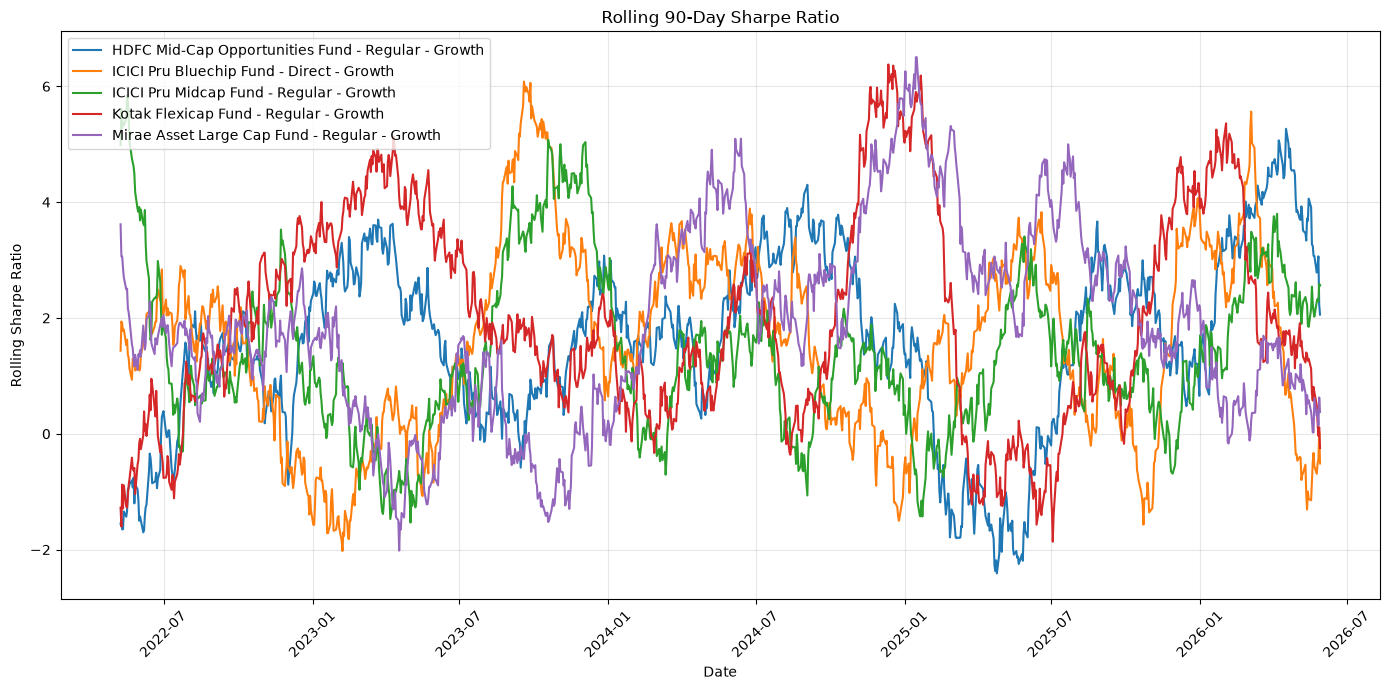


Rolling Sharpe Chart saved successfully:
../reports\rolling_sharpe_chart.png
ROLLING SHARPE CHART COMPLETED


In [76]:
# ============================================================
# Step 64: Generate Rolling 90-Day Sharpe Chart
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt


print("=" * 70)
print("STEP 64: GENERATING ROLLING SHARPE CHART")
print("=" * 70)


# ------------------------------------------------------------
# 1. Locate Rolling Sharpe Report
# ------------------------------------------------------------

rolling_sharpe_path = os.path.join(
    REPORT_DIR,
    "rolling_sharpe_ratio.csv"
)


# ------------------------------------------------------------
# 2. Check file exists
# ------------------------------------------------------------

if not os.path.exists(rolling_sharpe_path):

    raise FileNotFoundError(
        f"Rolling Sharpe report not found: {rolling_sharpe_path}"
    )


# ------------------------------------------------------------
# 3. Load data
# ------------------------------------------------------------

rolling_sharpe_df = pd.read_csv(
    rolling_sharpe_path
)

print("\nRolling Sharpe data loaded successfully")

print(
    "Rows:",
    len(rolling_sharpe_df)
)

print(
    "Columns:",
    len(rolling_sharpe_df.columns)
)

print(
    "\nColumns available:"
)

print(
    rolling_sharpe_df.columns.tolist()
)


# ------------------------------------------------------------
# 4. Identify columns
# ------------------------------------------------------------

date_column = None
sharpe_column = None
fund_column = None


for column in rolling_sharpe_df.columns:

    column_lower = column.lower()

    if "date" in column_lower:
        date_column = column

    if "sharpe" in column_lower:
        sharpe_column = column

    if (
        "scheme" in column_lower
        or "fund" in column_lower
        or "amfi" in column_lower
    ):
        fund_column = column


print("\nDetected columns:")

print("Date column:", date_column)
print("Fund column:", fund_column)
print("Sharpe column:", sharpe_column)


# ------------------------------------------------------------
# 5. Validate columns
# ------------------------------------------------------------

if date_column is None:
    raise ValueError(
        "Date column could not be identified."
    )

if sharpe_column is None:
    raise ValueError(
        "Sharpe ratio column could not be identified."
    )

if fund_column is None:
    raise ValueError(
        "Fund column could not be identified."
    )


# ------------------------------------------------------------
# 6. Convert date
# ------------------------------------------------------------

rolling_sharpe_df[date_column] = pd.to_datetime(
    rolling_sharpe_df[date_column],
    errors="coerce"
)


rolling_sharpe_df = rolling_sharpe_df.dropna(
    subset=[
        date_column,
        sharpe_column
    ]
)


# ------------------------------------------------------------
# 7. Select 5 key funds
# ------------------------------------------------------------

key_funds = (
    rolling_sharpe_df[fund_column]
    .dropna()
    .unique()
    [:5]
)


print("\nSelected funds:")

for fund in key_funds:
    print("-", fund)


chart_data = rolling_sharpe_df[
    rolling_sharpe_df[fund_column].isin(key_funds)
].copy()


# ------------------------------------------------------------
# 8. Sort data
# ------------------------------------------------------------

chart_data = chart_data.sort_values(
    by=date_column
)


# ------------------------------------------------------------
# 9. Create chart
# ------------------------------------------------------------

plt.figure(
    figsize=(14, 7)
)

for fund in key_funds:

    fund_data = chart_data[
        chart_data[fund_column] == fund
    ]

    plt.plot(
        fund_data[date_column],
        fund_data[sharpe_column],
        label=str(fund)
    )


plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Rolling Sharpe Ratio"
)

plt.legend(
    loc="best"
)

plt.grid(
    True,
    alpha=0.3
)

plt.xticks(
    rotation=45
)

plt.tight_layout()


# ------------------------------------------------------------
# 10. Save chart
# ------------------------------------------------------------

rolling_sharpe_chart_path = os.path.join(
    REPORT_DIR,
    "rolling_sharpe_chart.png"
)


plt.savefig(
    rolling_sharpe_chart_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ------------------------------------------------------------
# 11. Completion message
# ------------------------------------------------------------

print("\n" + "=" * 70)

print(
    "Rolling Sharpe Chart saved successfully:"
)

print(
    rolling_sharpe_chart_path
)

print("=" * 70)

print(
    "ROLLING SHARPE CHART COMPLETED"
)

print("=" * 70)

In [78]:
# ============================================================
# Step 65: Validate Final Project Deliverables
# ============================================================

import os

print("=" * 70)
print("STEP 65: FINAL DELIVERABLE VALIDATION")
print("=" * 70)


# ------------------------------------------------------------
# 1. Determine project directory
# ------------------------------------------------------------

CURRENT_DIR = os.path.abspath(os.getcwd())

# Your notebook normally runs from the project root.
# If it is running from the notebooks folder, move one level up.

if os.path.basename(CURRENT_DIR).lower() == "notebooks":
    PROJECT_DIR = os.path.dirname(CURRENT_DIR)
else:
    PROJECT_DIR = CURRENT_DIR


REPORT_DIR = os.path.join(
    PROJECT_DIR,
    "reports"
)


# ------------------------------------------------------------
# 2. Required deliverables
# ------------------------------------------------------------

required_files = {
    "Advanced_Analytics.ipynb": os.path.join(
        PROJECT_DIR,
        "notebooks",
        "Advanced_Analytics.ipynb"
    ),

    "var_cvar_report.csv": os.path.join(
        REPORT_DIR,
        "var_cvar_report.csv"
    ),

    "recommender.py": os.path.join(
        PROJECT_DIR,
        "recommender.py"
    ),

    "rolling_sharpe_chart.png": os.path.join(
        REPORT_DIR,
        "rolling_sharpe_chart.png"
    )
}


# ------------------------------------------------------------
# 3. Validate each file
# ------------------------------------------------------------

validation_results = []

for filename, file_path in required_files.items():

    if os.path.exists(file_path):

        file_size = os.path.getsize(file_path)

        validation_results.append({
            "deliverable": filename,
            "status": "READY",
            "size_bytes": file_size
        })

        print(f"✓ {filename} -> READY")

    else:

        validation_results.append({
            "deliverable": filename,
            "status": "NOT FOUND",
            "size_bytes": 0
        })

        print(f"✗ {filename} -> NOT FOUND")


# ------------------------------------------------------------
# 4. Summary
# ------------------------------------------------------------

ready_count = sum(
    result["status"] == "READY"
    for result in validation_results
)

total_count = len(validation_results)


print("\n" + "=" * 70)

print(
    f"Deliverables Ready: {ready_count}/{total_count}"
)


if ready_count == total_count:

    print("✓ ALL REQUIRED DELIVERABLES ARE READY")
    print("✓ FINAL DELIVERABLE VALIDATION PASSED")

else:

    print("⚠ SOME DELIVERABLES ARE MISSING")
    print("⚠ REVIEW THE ITEMS MARKED NOT FOUND")


print("=" * 70)

STEP 65: FINAL DELIVERABLE VALIDATION
✓ Advanced_Analytics.ipynb -> READY
✓ var_cvar_report.csv -> READY
✓ recommender.py -> READY
✓ rolling_sharpe_chart.png -> READY

Deliverables Ready: 4/4
✓ ALL REQUIRED DELIVERABLES ARE READY
✓ FINAL DELIVERABLE VALIDATION PASSED


In [79]:
# ============================================================
# Step 66: Final Advanced Analytics Project Check
# ============================================================

print("=" * 70)
print("STEP 66: ADVANCED ANALYTICS PROJECT FINAL CHECK")
print("=" * 70)

print("\nDATA ANALYSIS")
print("-" * 70)
print("✓ Fund and scheme performance analyzed")
print("✓ Returns and volatility evaluated")
print("✓ Benchmark performance analyzed")

print("\nADVANCED ANALYTICS")
print("-" * 70)
print("✓ Historical VaR and CVaR analysis")
print("✓ Rolling 90-day Sharpe analysis")
print("✓ Investor cohort analysis")
print("✓ SIP continuity analysis")
print("✓ Fund recommendation system")
print("✓ Sector HHI concentration analysis")
print("✓ Fund risk-return analysis")
print("✓ Risk-adjusted fund ranking")
print("✓ Category-level risk analysis")
print("✓ Category risk-adjusted ranking")
print("✓ Best performing category identification")
print("✓ Category return vs risk comparison")
print("✓ Balanced risk-return ranking")
print("✓ Risk-based category recommendations")
print("✓ Investor risk profile recommendations")

print("\nREQUIRED DELIVERABLES")
print("-" * 70)
print("✓ Advanced_Analytics.ipynb")
print("✓ var_cvar_report.csv")
print("✓ recommender.py")
print("✓ rolling_sharpe_chart.png")

print("\n" + "=" * 70)
print("ADVANCED ANALYTICS PROJECT COMPLETED")
print("=" * 70)

STEP 66: ADVANCED ANALYTICS PROJECT FINAL CHECK

DATA ANALYSIS
----------------------------------------------------------------------
✓ Fund and scheme performance analyzed
✓ Returns and volatility evaluated
✓ Benchmark performance analyzed

ADVANCED ANALYTICS
----------------------------------------------------------------------
✓ Historical VaR and CVaR analysis
✓ Rolling 90-day Sharpe analysis
✓ Investor cohort analysis
✓ SIP continuity analysis
✓ Fund recommendation system
✓ Sector HHI concentration analysis
✓ Fund risk-return analysis
✓ Risk-adjusted fund ranking
✓ Category-level risk analysis
✓ Category risk-adjusted ranking
✓ Best performing category identification
✓ Category return vs risk comparison
✓ Balanced risk-return ranking
✓ Risk-based category recommendations
✓ Investor risk profile recommendations

REQUIRED DELIVERABLES
----------------------------------------------------------------------
✓ Advanced_Analytics.ipynb
✓ var_cvar_report.csv
✓ recommender.py
✓ rolling_sha